# VLM Reliability Benchmark — Colab Runner

**Paper:** *Overconfident Under Pressure: A Reliability Benchmark of Small Open-Source VLMs Under Real-World Image Degradation*
**Author:** M M Asif Ferdous

---

## How to use this notebook

1. **Runtime → Change runtime type → T4 GPU** (free tier is enough)
2. Run cells **top to bottom**
3. Results checkpoint to Google Drive after every condition — if Colab
   disconnects, just re-run and it resumes.

## Before you start a full run
Run the **smoke test** (Section 6) first. It runs one image through the model.
If that works, the full run will work. If it fails, fix it there — don't
discover a problem 3 hours into a run.


---
## 1. Check GPU

If this says "No GPU", go to **Runtime → Change runtime type → T4 GPU**.


In [2]:
import subprocess
try:
    out = subprocess.check_output(["nvidia-smi"]).decode()
    print(out.split("\n")[8] if len(out.split("\n")) > 8 else out)
    print("\nGPU detected.")
except Exception as e:
    print("No GPU detected. Runtime -> Change runtime type -> T4 GPU")
    print(e)

import torch
print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1))


|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |

GPU detected.
torch: 2.11.0+cu128 | cuda available: True
device: Tesla T4
VRAM (GB): 15.6


In [3]:
import PIL, sys
print("python     :", sys.version.split()[0])
print("pillow     :", PIL.__version__)
try:
    import torch; print("torch      :", torch.__version__, "| cuda:", torch.cuda.is_available())
except Exception as e: print("torch      : FAIL", e)
try:
    import transformers; print("transformers:", transformers.__version__)
except Exception as e: print("transformers: FAIL", e)
try:
    import datasets; print("datasets   :", datasets.__version__)
except Exception as e: print("datasets   : MISSING")

from PIL import Image
import io
img = Image.new("RGB", (64,64), (120,80,200))
buf = io.BytesIO(); img.save(buf, format="JPEG"); buf.seek(0)
print("PIL JPEG round-trip:", Image.open(buf).convert("RGB").size, "OK")

python     : 3.12.13
pillow     : 11.3.0
torch      : 2.11.0+cu128 | cuda: True
transformers: 5.13.1
datasets   : 4.0.0
PIL JPEG round-trip: (64, 64) OK


---
## 2. Install dependencies

Takes ~2 minutes. If you hit a version error with the model later, the most
common fix is upgrading `transformers` — see Troubleshooting at the bottom.


---
## 3. Mount Google Drive (checkpointing)

**Do not skip this.** Colab disconnects. Without Drive you lose everything.

Results go to `MyDrive/vlm_reliability/`.


In [4]:
import os

USE_DRIVE = True   # set False if you really don't want Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/vlm_reliability'
else:
    OUT_DIR = '/content/vlm_reliability'

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(f"{OUT_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
print("Output dir:", OUT_DIR)


Mounted at /content/drive
Output dir: /content/drive/MyDrive/vlm_reliability


---
## 4. Core modules

Degradations, metrics, and the calibration fix — same code as your repo,
inlined so this notebook is self-contained.


In [5]:
# ---------------- degradations ----------------
import io
import numpy as np
from PIL import Image, ImageEnhance

def _to_rgb(img):
    return img.convert("RGB") if img.mode != "RGB" else img

def jpeg_compression(img, severity=2):
    img = _to_rgb(img)
    quality = {1: 30, 2: 15, 3: 7}[severity]
    buf = io.BytesIO(); img.save(buf, format="JPEG", quality=quality); buf.seek(0)
    return Image.open(buf).convert("RGB")

def motion_blur(img, severity=2):
    img = _to_rgb(img); radius = {1: 2, 2: 4, 3: 7}[severity]
    arr = np.asarray(img).astype(np.float32)
    acc = np.zeros_like(arr)
    for shift in range(-radius, radius + 1):
        acc += np.roll(arr, shift, axis=1)
    acc /= (radius * 2 + 1)
    return Image.fromarray(np.clip(acc, 0, 255).astype(np.uint8))

def low_light(img, severity=2):
    img = _to_rgb(img); factor = {1: 0.5, 2: 0.3, 3: 0.15}[severity]
    img = ImageEnhance.Brightness(img).enhance(factor)
    arr = np.asarray(img).astype(np.float32)
    sigma = {1: 5, 2: 10, 3: 18}[severity]
    arr += np.random.default_rng(0).normal(0, sigma, arr.shape)
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

def glare(img, severity=2):
    img = _to_rgb(img); factor = {1: 1.6, 2: 2.2, 3: 3.0}[severity]
    return ImageEnhance.Brightness(img).enhance(factor)

def rotation(img, severity=2):
    img = _to_rgb(img); angle = {1: 5, 2: 12, 3: 20}[severity]
    return img.rotate(angle, resample=Image.BILINEAR, expand=False, fillcolor=(0,0,0))

def resample(img, severity=2):
    img = _to_rgb(img); w, h = img.size
    scale = {1: 0.5, 2: 0.3, 3: 0.15}[severity]
    small = img.resize((max(1,int(w*scale)), max(1,int(h*scale))), Image.BILINEAR)
    return small.resize((w, h), Image.BILINEAR)

DEGRADATIONS = {"jpeg": jpeg_compression, "motion_blur": motion_blur,
                "low_light": low_light, "glare": glare,
                "rotation": rotation, "resample": resample}
SEVERITIES = [1, 2, 3]

def apply_degradation(img, name, severity):
    if name == "clean":
        return _to_rgb(img)
    return DEGRADATIONS[name](img, severity)

print("Degradations loaded:", ["clean"] + list(DEGRADATIONS))


Degradations loaded: ['clean', 'jpeg', 'motion_blur', 'low_light', 'glare', 'rotation', 'resample']


In [6]:
# ---------------- metrics ----------------
def _bin_stats(correct, confidence, n_bins=10):
    correct = np.asarray(correct, float); confidence = np.asarray(confidence, float)
    bins = np.linspace(0., 1., n_bins + 1)
    bin_ids = np.digitize(confidence, bins[1:-1], right=False)
    rows = []
    for b in range(n_bins):
        mask = bin_ids == b; count = int(mask.sum())
        if count == 0:
            rows.append(dict(bin=b, low=bins[b], high=bins[b+1], count=0,
                             conf=np.nan, acc=np.nan)); continue
        rows.append(dict(bin=b, low=float(bins[b]), high=float(bins[b+1]),
                         count=count, conf=float(confidence[mask].mean()),
                         acc=float(correct[mask].mean())))
    return rows

def expected_calibration_error(correct, confidence, n_bins=10):
    n = len(correct)
    if n == 0: return float("nan")
    ece = 0.
    for r in _bin_stats(correct, confidence, n_bins):
        if r["count"]: ece += (r["count"]/n) * abs(r["conf"] - r["acc"])
    return float(ece)

def maximum_calibration_error(correct, confidence, n_bins=10):
    gaps = [abs(r["conf"]-r["acc"]) for r in _bin_stats(correct, confidence, n_bins) if r["count"]]
    return float(max(gaps)) if gaps else float("nan")

def brier_score(correct, confidence):
    return float(np.mean((np.asarray(confidence,float) - np.asarray(correct,float))**2))

def error_detection_auroc(correct, confidence):
    correct = np.asarray(correct,int); confidence = np.asarray(confidence,float)
    pos, neg = confidence[correct==1], confidence[correct==0]
    if len(pos)==0 or len(neg)==0: return float("nan")
    allv = np.concatenate([pos,neg]); order = allv.argsort()
    ranks = np.empty_like(order,dtype=float); ranks[order] = np.arange(1,len(allv)+1)
    _, inv, counts = np.unique(allv, return_inverse=True, return_counts=True)
    tie = np.zeros(len(counts)); np.add.at(tie, inv, ranks)
    ranks = (tie/counts)[inv]
    r_pos = ranks[:len(pos)].sum()
    return float((r_pos - len(pos)*(len(pos)+1)/2) / (len(pos)*len(neg)))

def compute_all(correct, confidence, n_bins=10):
    return dict(n=int(len(correct)),
                accuracy=float(np.mean(correct)) if len(correct) else float("nan"),
                ece=expected_calibration_error(correct, confidence, n_bins),
                mce=maximum_calibration_error(correct, confidence, n_bins),
                brier=brier_score(correct, confidence),
                err_auroc=error_detection_auroc(correct, confidence))

# ---------------- calibration fix (RQ3) ----------------
def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1-eps); return np.log(p/(1-p))

def _sigmoid(x): return 1./(1.+np.exp(-x))

def apply_temperature(conf, T): return _sigmoid(_logit(np.asarray(conf,float))/T)

def fit_temperature(correct, conf, grid=None):
    if grid is None: grid = np.linspace(0.5, 5.0, 46)
    best_T, best = 1.0, float("inf")
    for T in grid:
        e = expected_calibration_error(correct, apply_temperature(conf, T))
        if e < best: best, best_T = e, T
    return float(best_T)

print("Metrics + calibration loaded.")


Metrics + calibration loaded.


---
## 5. Dataset

We use **Oxford-IIIT Pet** (37 breeds, real photographs) posed as 4-way
multiple choice. Real photos at usable resolution — appropriate for a
corruption study, unlike tiny 32×32 datasets.

Downloads ~800MB the first time.

**`N_ITEMS` is the main cost lever.** Start at 100 for a pilot. A full run is
`N_ITEMS × 19 conditions` generations, so 100 items ≈ 1,900 generations
(roughly 1–2 hours on a T4 for a 2B model).


README.md:   0%|          | 0.00/16.4k [00:00<?, ?B/s]

  food101 unavailable (HfUriError)


README.md:   0%|          | 0.00/16.4k [00:00<?, ?B/s]

Using dataset: ethz/food101  (101 classes)
Built 100 items from ethz/food101
  Q: What food is shown in the image?
  options: ['hamburger', 'tiramisu', 'grilled cheese sandwich', 'takoyaki']
  gold: takoyaki


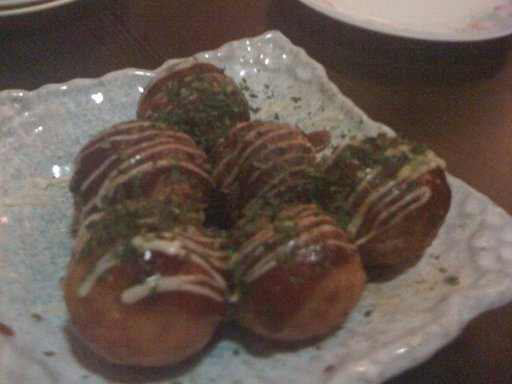

In [7]:
import random, itertools
from datasets import load_dataset

N_ITEMS   = 100
SEED      = 0
N_OPTIONS = 4

CANDIDATES = [
    ("food101",     "validation", "image", "label"),
    ("ethz/food101","validation", "image", "label"),
    ("cifar100",    "test",       "img",   "fine_label"),
]

picked = None
for name, split, ik, lk in CANDIDATES:
    try:
        ds = load_dataset(name, split=split, streaming=True)
        classes = ds.features[lk].names
        picked = (ds, ik, lk, classes, name)
        print(f"Using dataset: {name}  ({len(classes)} classes)")
        break
    except Exception as e:
        print(f"  {name} unavailable ({type(e).__name__})")

if picked is None:
    raise RuntimeError("No dataset loaded - send Claude the messages above.")

ds, IK, LK, classes, ds_name = picked
rng = random.Random(SEED)

def clean(c):
    return str(c).replace("_", " ").replace("-", " ").strip()

CLASS_NAMES = [clean(c) for c in classes]

stream = ds.shuffle(seed=SEED, buffer_size=500)
ITEMS = []
for row in itertools.islice(stream, N_ITEMS):
    img  = row[IK].convert("RGB")
    gold = CLASS_NAMES[row[LK]]
    distractors = rng.sample([c for c in CLASS_NAMES if c != gold], N_OPTIONS - 1)
    options = [gold] + distractors
    rng.shuffle(options)
    ITEMS.append(dict(image=img, gold=gold, options=options,
                      question="What food is shown in the image?"))

print(f"Built {len(ITEMS)} items from {ds_name}")
print("  Q:", ITEMS[0]["question"])
print("  options:", ITEMS[0]["options"])
print("  gold:", ITEMS[0]["gold"])
ITEMS[0]["image"]

---
## 6. Load model + smoke test

Default: **Qwen2-VL-2B-Instruct** (~4.4GB download, fits comfortably on a T4).

To swap models later, change `MODEL_ID`. Other small open options to try:
`Qwen/Qwen2-VL-7B-Instruct` (needs 4-bit on T4), `HuggingFaceTB/SmolVLM-Instruct`.

> **Note:** model-loading APIs change between `transformers` versions. If the
> load cell errors, open the model card on Hugging Face and copy its current
> usage snippet — that page is always the source of truth, not this notebook.


In [8]:
import torch, re
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID)

# transformers 5.x renamed torch_dtype -> dtype
try:
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_ID, dtype=torch.float16, device_map="auto")
except TypeError:
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto")

model.eval()
print("Loaded:", MODEL_ID)
print("device:", next(model.parameters()).device)

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2-VL-2B-Instruct
device: cuda:0


In [9]:
# ---------------- prompting + parsing ----------------
CONFIDENCE_PROMPT = (
    "Look at the image and answer the question.\n"
    "Question: {question}\n"
    "Options: {options}\n\n"
    "Respond in EXACTLY this format:\n"
    "Answer: <one option, copied exactly>\n"
    "Confidence: <an integer from 0 to 100>\n"
)

# RQ3 variant — quality-aware elicitation (our backup contribution)
CONFIDENCE_PROMPT_QUALITY_AWARE = (
    "Look at the image and answer the question.\n"
    "First briefly note whether the image is clear or degraded (blurry, dark, "
    "compressed), because that should affect how confident you are.\n"
    "Question: {question}\n"
    "Options: {options}\n\n"
    "Respond in EXACTLY this format:\n"
    "Reasoning: <one short sentence on image quality>\n"
    "Answer: <one option, copied exactly>\n"
    "Confidence: <an integer from 0 to 100>\n"
)

def parse_answer_and_confidence(text):
    answer, conf = "", None
    m = re.search(r"Answer:\s*(.+)", text, re.IGNORECASE)
    if m: answer = m.group(1).strip().splitlines()[0].strip()
    m = re.search(r"Confidence:\s*([0-9]{1,3}(?:\.[0-9]+)?)", text, re.IGNORECASE)
    if m: conf = max(0., min(1., float(m.group(1))/100.))
    return answer, conf

@torch.no_grad()
def ask(image, question, options, prompt_template=CONFIDENCE_PROMPT, max_new_tokens=64):
    prompt = prompt_template.format(question=question, options=", ".join(options))
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt}]}]
    try:
        inputs = processor.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=True,
            return_dict=True, return_tensors="pt")
        inputs = {k: (v.to(model.device) if hasattr(v, "to") else v)
                  for k, v in inputs.items()}
    except Exception:
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image],
                           return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    in_len = inputs["input_ids"].shape[1]
    return processor.decode(out[0][in_len:], skip_special_tokens=True)

print("Prompting utilities ready.")


Prompting utilities ready.


### Smoke test — run this before any full run

One image, printed raw output. You are checking:
- does the model produce text at all?
- does it follow the `Answer:` / `Confidence:` format?

If the format isn't followed, **fix the prompt now**. A high parse-failure rate
ruins the calibration analysis.


In [10]:
it = ITEMS[0]
raw_out = ask(it["image"], it["question"], it["options"])
print("--- RAW MODEL OUTPUT ---")
print(raw_out)
print("--- PARSED ---")
ans, conf = parse_answer_and_confidence(raw_out)
print("answer:", repr(ans), "| confidence:", conf, "| gold:", repr(it["gold"]))

# also sanity-check a degraded version
deg = apply_degradation(it["image"], "motion_blur", 3)
raw_out2 = ask(deg, it["question"], it["options"])
print("\n--- DEGRADED (motion_blur s3) ---")
print(raw_out2)


--- RAW MODEL OUTPUT ---
takoyaki
--- PARSED ---
answer: '' | confidence: None | gold: 'takoyaki'

--- DEGRADED (motion_blur s3) ---
takoyaki


In [11]:
import glob, os
bad = glob.glob(f"{OUT_DIR}/checkpoints/*.csv")
for p in bad:
    os.remove(p)
print(f"Deleted {len(bad)} checkpoint files")

Deleted 19 checkpoint files


In [12]:
PROMPT_A = (
    "Question: {question}\n"
    "Options: {options}\n\n"
    "Answer the question, then rate your confidence from 0 to 100.\n"
    "Use exactly this format and nothing else:\n"
    "Answer: <option>\n"
    "Confidence: <number>"
)

PROMPT_B = (
    "You must reply in exactly two lines.\n\n"
    "Example reply:\n"
    "Answer: pizza\n"
    "Confidence: 85\n\n"
    "Now do the same for this image.\n"
    "Question: {question}\n"
    "Options: {options}"
)

PROMPT_C = (
    "{question}\n"
    "Choose one: {options}\n\n"
    "Reply with two lines only:\n"
    "Answer: (your choice)\n"
    "Confidence: (0-100)"
)

for name, tmpl in [("A", PROMPT_A), ("B", PROMPT_B), ("C", PROMPT_C)]:
    ok = 0
    print(f"\n===== PROMPT {name} =====")
    for it in ITEMS[:5]:
        out = ask(it["image"], it["question"], it["options"], tmpl, max_new_tokens=48)
        a, c = parse_answer_and_confidence(out)
        if c is not None: ok += 1
        print(f"  raw: {out.strip()[:70]!r}  -> conf={c}")
    print(f"  PARSE SUCCESS: {ok}/5")


===== PROMPT A =====
  raw: '100'  -> conf=None
  raw: '100'  -> conf=None
  raw: '100'  -> conf=None
  raw: '100'  -> conf=None
  raw: '100'  -> conf=None
  PARSE SUCCESS: 0/5

===== PROMPT B =====
  raw: 'Answer: takoyaki\nConfidence: 90'  -> conf=0.9
  raw: 'Answer: cheese plate\nConfidence: 90'  -> conf=0.9
  raw: 'Answer: cheese plate\nConfidence: 90'  -> conf=0.9
  raw: 'Answer: pho\nConfidence: 90'  -> conf=0.9
  raw: 'Answer: pho\nConfidence: 90'  -> conf=0.9
  PARSE SUCCESS: 5/5

===== PROMPT C =====
  raw: 'Takoyaki'  -> conf=None
  raw: 'Cheese plate'  -> conf=None
  raw: 'Cheese plate'  -> conf=None
  raw: 'Pho'  -> conf=None
  raw: 'Pho'  -> conf=None
  PARSE SUCCESS: 0/5


In [13]:
CONFIDENCE_PROMPT = PROMPT_B
print("Default prompt set to B")
print(CONFIDENCE_PROMPT)

Default prompt set to B
You must reply in exactly two lines.

Example reply:
Answer: pizza
Confidence: 85

Now do the same for this image.
Question: {question}
Options: {options}


---
## 7. Answer matching

VLMs rarely return a string that matches the gold label exactly — they add
articles, change case, or paraphrase. Naive string equality would understate
accuracy badly and corrupt every downstream metric.

We use normalised matching with a containment fallback, and **record the match
method** so you can report it honestly in the paper.


In [14]:
def normalize(s):
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def match_answer(pred, gold, options):
    """Return (is_correct, method). Method recorded for transparency."""
    p, g = normalize(pred), normalize(gold)
    if not p: return 0, "empty"
    if p == g: return 1, "exact"
    # does the prediction contain the gold, and no other option?
    contains = [o for o in options if normalize(o) in p]
    if len(contains) == 1:
        return int(normalize(contains[0]) == g), "contains_unique"
    if g in p: return 1, "contains_gold"
    return 0, "no_match"

# quick check
print(match_answer("Answer: the Abyssinian", "Abyssinian", ["Abyssinian","Beagle"]))
print(match_answer("Beagle", "Abyssinian", ["Abyssinian","Beagle"]))


(1, 'contains_unique')
(0, 'contains_unique')


---
## 8. Main experiment run (with checkpointing)

Runs `models × degradations × severities`. After **each condition** it writes a
checkpoint CSV to Drive. If Colab disconnects, re-run this cell — completed
conditions are skipped automatically.

Set `PROMPT_MODE` to `"standard"` for the main results, then re-run with
`"quality_aware"` for the RQ3 prompt-based comparison.


In [15]:
import csv, time, glob

PROMPT_MODE = "standard"    # or "quality_aware"
CONDITIONS = ["clean", "jpeg", "motion_blur", "low_light", "glare", "rotation", "resample"]

TEMPLATE = CONFIDENCE_PROMPT if PROMPT_MODE == "standard" else CONFIDENCE_PROMPT_QUALITY_AWARE
RUN_TAG = f"{MODEL_ID.split('/')[-1]}_{PROMPT_MODE}"

def ckpt_path(cond, sev):
    return f"{OUT_DIR}/checkpoints/{RUN_TAG}__{cond}__s{sev}.csv"

def run_condition(cond, sev):
    path = ckpt_path(cond, sev)
    if os.path.exists(path):
        print(f"  skip (done): {cond} s{sev}")
        return
    rows = []
    t0 = time.time()
    for i, it in enumerate(ITEMS):
        img = apply_degradation(it["image"], cond, max(sev, 1))
        try:
            out = ask(img, it["question"], it["options"], TEMPLATE)
        except Exception as e:
            out = f"<ERROR: {e}>"
        pred, conf = parse_answer_and_confidence(out)
        correct, method = match_answer(pred, it["gold"], it["options"])
        rows.append(dict(model=MODEL_ID, prompt_mode=PROMPT_MODE,
                         degradation=cond, severity=sev, item=i,
                         gold=it["gold"], answer=pred,
                         confidence="" if conf is None else round(conf,4),
                         correct="" if conf is None else correct,
                         match_method=method, raw=out.replace("\n"," | ")[:300]))
        if (i+1) % 25 == 0:
            print(f"    {cond} s{sev}: {i+1}/{len(ITEMS)}  ({time.time()-t0:.0f}s)")
    with open(path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print(f"  saved {path}  ({time.time()-t0:.0f}s)")

print(f"Run tag: {RUN_TAG}\n")
for cond in CONDITIONS:
    for sev in ([0] if cond == "clean" else SEVERITIES):
        run_condition(cond, sev)
print("\nAll conditions complete.")


Run tag: Qwen2-VL-2B-Instruct_standard

    clean s0: 25/100  (18s)
    clean s0: 50/100  (37s)
    clean s0: 75/100  (60s)
    clean s0: 100/100  (79s)
  saved /content/drive/MyDrive/vlm_reliability/checkpoints/Qwen2-VL-2B-Instruct_standard__clean__s0.csv  (79s)
    jpeg s1: 25/100  (18s)
    jpeg s1: 50/100  (38s)
    jpeg s1: 75/100  (56s)
    jpeg s1: 100/100  (75s)
  saved /content/drive/MyDrive/vlm_reliability/checkpoints/Qwen2-VL-2B-Instruct_standard__jpeg__s1.csv  (75s)
    jpeg s2: 25/100  (19s)
    jpeg s2: 50/100  (38s)
    jpeg s2: 75/100  (56s)
    jpeg s2: 100/100  (76s)
  saved /content/drive/MyDrive/vlm_reliability/checkpoints/Qwen2-VL-2B-Instruct_standard__jpeg__s2.csv  (76s)
    jpeg s3: 25/100  (19s)
    jpeg s3: 50/100  (37s)
    jpeg s3: 75/100  (56s)
    jpeg s3: 100/100  (74s)
  saved /content/drive/MyDrive/vlm_reliability/checkpoints/Qwen2-VL-2B-Instruct_standard__jpeg__s3.csv  (74s)
    motion_blur s1: 25/100  (19s)
    motion_blur s1: 50/100  (37s)
    motion_

---
## 9. Aggregate results

Loads all checkpoints and computes the summary table — this becomes **Table 1
and Table 2** of your paper.

Watch the `parse_fail_rate` column. If it's high (say >10%) for some condition,
the model is not following the output format there — that is itself a finding
worth reporting, but it also weakens the calibration numbers for that cell.


In [16]:
import csv

def load_all(tag=RUN_TAG):
    rows = []
    for p in sorted(glob.glob(f"{OUT_DIR}/checkpoints/{tag}__*.csv")):
        with open(p) as f:
            rows.extend(list(csv.DictReader(f)))
    return rows

rows = load_all()
print(f"Loaded {len(rows)} predictions")

from collections import defaultdict
groups = defaultdict(list)
for r in rows:
    groups[(r["degradation"], int(r["severity"]))].append(r)

summary = []
for (cond, sev), rs in sorted(groups.items()):
    usable = [r for r in rs if r["confidence"] != ""]
    fail_rate = 1 - len(usable)/len(rs) if rs else float("nan")
    if not usable:
        continue
    correct = [int(r["correct"]) for r in usable]
    conf = [float(r["confidence"]) for r in usable]
    m = compute_all(correct, conf)
    m.update(degradation=cond, severity=sev, parse_fail_rate=round(fail_rate,3))
    summary.append(m)

fields = ["degradation","severity","n","accuracy","ece","mce","brier","err_auroc","parse_fail_rate"]
print("\n" + " | ".join(f"{f:>14s}" for f in fields))
for s in summary:
    print(" | ".join(f"{str(round(s[f],3) if isinstance(s.get(f),float) else s.get(f)):>14s}" for f in fields))

with open(f"{OUT_DIR}/summary_{RUN_TAG}.csv","w",newline="") as f:
    w = csv.DictWriter(f, fieldnames=fields); w.writeheader()
    for s in summary: w.writerow({k:s.get(k) for k in fields})
print(f"\nSaved {OUT_DIR}/summary_{RUN_TAG}.csv")


Loaded 1900 predictions

   degradation |       severity |              n |       accuracy |            ece |            mce |          brier |      err_auroc | parse_fail_rate
         clean |              0 |             99 |           0.99 |           0.09 |           0.15 |          0.018 |          0.495 |           0.01
         glare |              1 |             99 |           0.98 |           0.08 |           0.08 |          0.026 |            0.5 |           0.01
         glare |              2 |             99 |          0.929 |          0.061 |          0.467 |          0.063 |          0.637 |           0.01
         glare |              3 |            100 |           0.87 |          0.055 |           0.81 |          0.106 |          0.692 |            0.0
          jpeg |              1 |            100 |           0.99 |          0.107 |           0.85 |          0.017 |            1.0 |            0.0
          jpeg |              2 |             99 |           0.99 | 

---
## 10. RQ3 — the training-free fix

Fit temperature `T` on a **clean-image split only**, then apply it unchanged to
every degraded condition. This is the honest protocol: the fix never sees
degraded data, mirroring deployment where you can't anticipate the corruption.

**If ECE improves → that's your headline result.
If it doesn't → that is still a publishable, honest finding.** Report whichever
you actually get. Do not tune until it looks good — that's how papers become
irreproducible.


In [17]:
clean_rows = [r for r in rows if r["degradation"]=="clean" and r["confidence"]!=""]
if len(clean_rows) < 20:
    print("Not enough clean rows to fit temperature.")
else:
    split = len(clean_rows)//2
    fit_rows = clean_rows[:split]
    T = fit_temperature([int(r["correct"]) for r in fit_rows],
                        [float(r["confidence"]) for r in fit_rows])
    print(f"Fitted T = {T:.2f} (on {len(fit_rows)} clean items)\n")

    print(f"{'condition':>22s} | {'ECE before':>10s} | {'ECE after':>9s} | {'Brier before':>12s} | {'Brier after':>11s}")
    fix_rows = []
    for (cond, sev), rs in sorted(groups.items()):
        usable = [r for r in rs if r["confidence"] != ""]
        if len(usable) < 10: continue
        c = np.array([int(r["correct"]) for r in usable])
        p = np.array([float(r["confidence"]) for r in usable])
        p2 = apply_temperature(p, T)
        e1, e2 = expected_calibration_error(c,p), expected_calibration_error(c,p2)
        b1, b2 = brier_score(c,p), brier_score(c,p2)
        label = f"{cond} s{sev}"
        print(f"{label:>22s} | {e1:>10.3f} | {e2:>9.3f} | {b1:>12.3f} | {b2:>11.3f}")
        fix_rows.append(dict(degradation=cond, severity=sev, T=round(T,3),
                             ece_before=round(e1,4), ece_after=round(e2,4),
                             brier_before=round(b1,4), brier_after=round(b2,4)))

    with open(f"{OUT_DIR}/calibration_fix_{RUN_TAG}.csv","w",newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(fix_rows[0].keys()))
        w.writeheader(); w.writerows(fix_rows)
    print(f"\nSaved {OUT_DIR}/calibration_fix_{RUN_TAG}.csv")


Fitted T = 0.50 (on 49 clean items)

             condition | ECE before | ECE after | Brier before | Brier after
              clean s0 |      0.090 |     0.002 |        0.018 |       0.010
              glare s1 |      0.080 |     0.008 |        0.026 |       0.020
              glare s2 |      0.061 |     0.057 |        0.063 |       0.067
              glare s3 |      0.055 |     0.116 |        0.106 |       0.123
               jpeg s1 |      0.107 |     0.002 |        0.017 |       0.010
               jpeg s2 |      0.107 |     0.002 |        0.017 |       0.010
               jpeg s3 |      0.112 |     0.028 |        0.039 |       0.038
          low_light s1 |      0.103 |     0.007 |        0.022 |       0.010
          low_light s2 |      0.039 |     0.067 |        0.075 |       0.080
          low_light s3 |      0.650 |     0.756 |        0.590 |       0.742
        motion_blur s1 |      0.099 |     0.012 |        0.010 |       0.000
        motion_blur s2 |      0.107 |  

---
## 11. Figures

Generates the paper figures into Drive.


In [18]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Fig 1 + 2: metric vs severity
for metric in ["ece", "accuracy"]:
    plt.figure(figsize=(7,4.5))
    series = defaultdict(list)
    for s in summary:
        if s["degradation"] == "clean": continue
        series[s["degradation"]].append((s["severity"], s[metric]))
    for deg, pts in sorted(series.items()):
        pts.sort()
        plt.plot([p[0] for p in pts], [p[1] for p in pts], marker="o", label=deg)
    plt.xlabel("Corruption severity"); plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} vs. severity — {MODEL_ID.split('/')[-1]}")
    plt.xticks([1,2,3]); plt.legend(fontsize=8, ncol=2); plt.grid(alpha=0.3)
    plt.tight_layout()
    p = f"{OUT_DIR}/figures/fig_{metric}_vs_severity_{RUN_TAG}.png"
    plt.savefig(p, dpi=150); plt.close(); print("saved", p)

# Fig 3: reliability diagram
def reliability_fig(cond, sev):
    rs = [r for r in groups[(cond,sev)] if r["confidence"]!=""]
    if len(rs) < 10: return
    c = np.array([int(r["correct"]) for r in rs])
    p = np.array([float(r["confidence"]) for r in rs])
    bins = _bin_stats(c, p, 10)
    centers = [(b["low"]+b["high"])/2 for b in bins]
    accs = [b["acc"] if b["count"]>0 else 0 for b in bins]
    plt.figure(figsize=(5,5))
    plt.plot([0,1],[0,1],"--",color="gray",label="perfect calibration")
    plt.bar(centers, accs, width=0.09, alpha=0.7, edgecolor="black", label="model")
    plt.xlabel("Stated confidence"); plt.ylabel("Actual accuracy")
    plt.title(f"Reliability: {cond} s{sev}")
    plt.xlim(0,1); plt.ylim(0,1); plt.legend(fontsize=8); plt.tight_layout()
    path = f"{OUT_DIR}/figures/fig_reliability_{cond}_s{sev}_{RUN_TAG}.png"
    plt.savefig(path, dpi=150); plt.close(); print("saved", path)

reliability_fig("clean", 0)
for c in ["jpeg","motion_blur","low_light"]:
    reliability_fig(c, 3)
print("\nFigures in", f"{OUT_DIR}/figures/")


saved /content/drive/MyDrive/vlm_reliability/figures/fig_ece_vs_severity_Qwen2-VL-2B-Instruct_standard.png
saved /content/drive/MyDrive/vlm_reliability/figures/fig_accuracy_vs_severity_Qwen2-VL-2B-Instruct_standard.png
saved /content/drive/MyDrive/vlm_reliability/figures/fig_reliability_clean_s0_Qwen2-VL-2B-Instruct_standard.png
saved /content/drive/MyDrive/vlm_reliability/figures/fig_reliability_jpeg_s3_Qwen2-VL-2B-Instruct_standard.png
saved /content/drive/MyDrive/vlm_reliability/figures/fig_reliability_motion_blur_s3_Qwen2-VL-2B-Instruct_standard.png
saved /content/drive/MyDrive/vlm_reliability/figures/fig_reliability_low_light_s3_Qwen2-VL-2B-Instruct_standard.png

Figures in /content/drive/MyDrive/vlm_reliability/figures/


In [19]:
# ============================================================
#  Internal (token-level) confidence extraction
#  Adds a second, continuous confidence signal alongside verbalized.
# ============================================================
import torch, csv, os, time, glob
import numpy as np

@torch.no_grad()
def ask_with_internal(image, question, options,
                      prompt_template=CONFIDENCE_PROMPT, max_new_tokens=48):
    """
    Returns (decoded_text, internal_conf).

    internal_conf = mean token probability over the generated answer span,
    i.e. how confident the model's own distribution was while producing text.
    Continuous in (0,1], unlike the verbalized number.
    """
    prompt = prompt_template.format(question=question, options=", ".join(options))
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt}]}]
    try:
        inputs = processor.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=True,
            return_dict=True, return_tensors="pt")
        inputs = {k: (v.to(model.device) if hasattr(v, "to") else v)
                  for k, v in inputs.items()}
    except Exception:
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image],
                           return_tensors="pt").to(model.device)

    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
                         do_sample=False,
                         return_dict_in_generate=True,
                         output_scores=True)

    in_len = inputs["input_ids"].shape[1]
    seq = out.sequences[0][in_len:]
    decoded = processor.decode(seq, skip_special_tokens=True)

    # probability of each chosen token
    probs = []
    for step, score in enumerate(out.scores):
        if step >= len(seq):
            break
        p = torch.softmax(score[0].float(), dim=-1)[seq[step]].item()
        probs.append(p)

    internal = float(np.mean(probs)) if probs else None
    return decoded, internal


# ---- quick sanity check on 5 items before the full run ----
print("Sanity check (internal confidence should VARY):")
vals = []
for it in ITEMS[:5]:
    txt, ic = ask_with_internal(it["image"], it["question"], it["options"])
    a, vc = parse_answer_and_confidence(txt)
    vals.append(ic)
    print(f"  verbalized={vc}  internal={ic:.4f}  ans={a!r}")
print(f"\n  internal range: {min(vals):.4f} - {max(vals):.4f}")
print("  If these differ from each other, we're good. If all identical, tell Claude.")

Sanity check (internal confidence should VARY):
  verbalized=0.9  internal=0.9033  ans='takoyaki'
  verbalized=0.9  internal=0.8831  ans='cheese plate'
  verbalized=0.9  internal=0.9043  ans='cheese plate'
  verbalized=0.9  internal=0.8670  ans='pho'
  verbalized=0.9  internal=0.8604  ans='pho'

  internal range: 0.8604 - 0.9043
  If these differ from each other, we're good. If all identical, tell Claude.


In [20]:
# ============================================================
#  Full run: verbalized + internal confidence, both signals
#  Separate checkpoints (RUN_TAG2) so nothing overwrites last night.
# ============================================================
import csv, os, time, glob

RUN_TAG2 = f"{MODEL_ID.split('/')[-1]}_dual"
os.makedirs(f"{OUT_DIR}/checkpoints", exist_ok=True)

def ckpt2(cond, sev):
    return f"{OUT_DIR}/checkpoints/{RUN_TAG2}__{cond}__s{sev}.csv"

def run_condition_dual(cond, sev):
    path = ckpt2(cond, sev)
    if os.path.exists(path):
        print(f"  skip (done): {cond} s{sev}")
        return
    rows, t0 = [], time.time()
    for i, it in enumerate(ITEMS):
        img = apply_degradation(it["image"], cond, max(sev, 1))
        try:
            out, internal = ask_with_internal(img, it["question"], it["options"])
        except Exception as e:
            out, internal = f"<ERROR: {e}>", None
        pred, verb = parse_answer_and_confidence(out)
        correct, method = match_answer(pred, it["gold"], it["options"])
        rows.append(dict(
            model=MODEL_ID, degradation=cond, severity=sev, item=i,
            gold=it["gold"], answer=pred,
            verbalized="" if verb is None else round(verb, 4),
            internal="" if internal is None else round(internal, 6),
            correct="" if verb is None and internal is None else correct,
            match_method=method,
            raw=out.replace("\n", " | ")[:200]))
        if (i + 1) % 50 == 0:
            print(f"    {cond} s{sev}: {i+1}/{len(ITEMS)}  ({time.time()-t0:.0f}s)")
    with open(path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print(f"  saved {cond} s{sev}  ({time.time()-t0:.0f}s)")

print(f"Run tag: {RUN_TAG2}\n")
for cond in CONDITIONS:
    for sev in ([0] if cond == "clean" else SEVERITIES):
        run_condition_dual(cond, sev)
print("\nDual-signal run complete.")

Run tag: Qwen2-VL-2B-Instruct_dual

    clean s0: 50/100  (43s)
    clean s0: 100/100  (81s)
  saved clean s0  (81s)
    jpeg s1: 50/100  (37s)
    jpeg s1: 100/100  (76s)
  saved jpeg s1  (76s)
    jpeg s2: 50/100  (38s)
    jpeg s2: 100/100  (75s)
  saved jpeg s2  (75s)
    jpeg s3: 50/100  (38s)
    jpeg s3: 100/100  (77s)
  saved jpeg s3  (77s)
    motion_blur s1: 50/100  (37s)
    motion_blur s1: 100/100  (75s)
  saved motion_blur s1  (75s)
    motion_blur s2: 50/100  (38s)
    motion_blur s2: 100/100  (76s)
  saved motion_blur s2  (76s)
    motion_blur s3: 50/100  (38s)
    motion_blur s3: 100/100  (77s)
  saved motion_blur s3  (77s)
    low_light s1: 50/100  (39s)
    low_light s1: 100/100  (78s)
  saved low_light s1  (78s)
    low_light s2: 50/100  (39s)
    low_light s2: 100/100  (76s)
  saved low_light s2  (76s)
    low_light s3: 50/100  (38s)
    low_light s3: 100/100  (76s)
  saved low_light s3  (76s)
    glare s1: 50/100  (38s)
    glare s1: 100/100  (76s)
  saved glare s1

In [21]:
# ============================================================
#  Dual-signal analysis: verbalized vs internal confidence
# ============================================================
import csv, glob
import numpy as np
from collections import defaultdict

rows2 = []
for p in sorted(glob.glob(f"{OUT_DIR}/checkpoints/{RUN_TAG2}__*.csv")):
    with open(p) as f:
        rows2.extend(list(csv.DictReader(f)))
print(f"Loaded {len(rows2)} dual-signal predictions\n")

groups2 = defaultdict(list)
for r in rows2:
    groups2[(r["degradation"], int(r["severity"]))].append(r)

def order_key(k):
    cond, sev = k
    return (0 if cond == "clean" else 1, cond, sev)

hdr = (f"{'condition':>16s} | {'acc':>5s} | {'verb':>5s} | {'int':>6s} | "
       f"{'ECE_v':>6s} | {'ECE_i':>6s} | {'AUROC_v':>7s} | {'AUROC_i':>7s}")
print(hdr); print("-" * len(hdr))

summary2 = []
for key in sorted(groups2, key=order_key):
    cond, sev = key
    rs = [r for r in groups2[key] if r["correct"] != ""]
    if len(rs) < 10:
        continue
    c  = np.array([int(r["correct"]) for r in rs])
    v  = np.array([float(r["verbalized"]) for r in rs if r["verbalized"] != ""])
    i_ = np.array([float(r["internal"])   for r in rs if r["internal"]   != ""])
    cv = c[:len(v)]; ci = c[:len(i_)]

    m = dict(
        degradation=cond, severity=sev, n=len(rs),
        accuracy=float(c.mean()),
        verb_mean=float(v.mean()) if len(v) else float("nan"),
        int_mean=float(i_.mean()) if len(i_) else float("nan"),
        ece_verb=expected_calibration_error(cv, v) if len(v) else float("nan"),
        ece_int=expected_calibration_error(ci, i_) if len(i_) else float("nan"),
        brier_verb=brier_score(cv, v) if len(v) else float("nan"),
        brier_int=brier_score(ci, i_) if len(i_) else float("nan"),
        auroc_verb=error_detection_auroc(cv, v) if len(v) else float("nan"),
        auroc_int=error_detection_auroc(ci, i_) if len(i_) else float("nan"),
    )
    summary2.append(m)
    print(f"{cond+' s'+str(sev):>16s} | {m['accuracy']:>5.2f} | "
          f"{m['verb_mean']:>5.2f} | {m['int_mean']:>6.3f} | "
          f"{m['ece_verb']:>6.3f} | {m['ece_int']:>6.3f} | "
          f"{m['auroc_verb']:>7.3f} | {m['auroc_int']:>7.3f}")

fields2 = ["degradation","severity","n","accuracy","verb_mean","int_mean",
           "ece_verb","ece_int","brier_verb","brier_int","auroc_verb","auroc_int"]
with open(f"{OUT_DIR}/summary_dual_{RUN_TAG2}.csv","w",newline="") as f:
    w = csv.DictWriter(f, fieldnames=fields2); w.writeheader()
    for s in summary2: w.writerow({k: s.get(k) for k in fields2})
print(f"\nSaved {OUT_DIR}/summary_dual_{RUN_TAG2}.csv")

# ---- the key comparison ----
print("\n" + "="*62)
print("KEY QUESTION: does internal confidence track accuracy better?")
print("="*62)
cl = [s for s in summary2 if s["degradation"]=="clean"]
ll = [s for s in summary2 if s["degradation"]=="low_light" and s["severity"]==3]
if cl and ll:
    a, b = cl[0], ll[0]
    print(f"  clean        : acc={a['accuracy']:.2f}  verb={a['verb_mean']:.3f}  int={a['int_mean']:.3f}")
    print(f"  low_light s3 : acc={b['accuracy']:.2f}  verb={b['verb_mean']:.3f}  int={b['int_mean']:.3f}")
    print(f"\n  accuracy drop : {a['accuracy']-b['accuracy']:+.3f}")
    print(f"  verbalized    : {b['verb_mean']-a['verb_mean']:+.3f}  (should drop if honest)")
    print(f"  internal      : {b['int_mean']-a['int_mean']:+.3f}  (should drop if honest)")

Loaded 1900 dual-signal predictions

       condition |   acc |  verb |    int |  ECE_v |  ECE_i | AUROC_v | AUROC_i
-------------------------------------------------------------------------------
        clean s0 |  0.99 |  0.90 |  0.883 |  0.090 |  0.107 |   0.495 |   0.919
        glare s1 |  0.98 |  0.90 |  0.881 |  0.080 |  0.099 |   0.500 |   0.821
        glare s2 |  0.93 |  0.90 |  0.879 |  0.061 |  0.065 |   0.637 |   0.851
        glare s3 |  0.87 |  0.90 |  0.875 |  0.055 |  0.033 |   0.692 |   0.909
         jpeg s1 |  0.99 |  0.90 |  0.892 |  0.107 |  0.098 |   1.000 |   0.990
         jpeg s2 |  0.99 |  0.90 |  0.892 |  0.107 |  0.098 |   1.000 |   0.990
         jpeg s3 |  0.95 |  0.90 |  0.880 |  0.061 |  0.099 |   0.588 |   0.962
    low_light s1 |  0.99 |  0.89 |  0.873 |  0.103 |  0.117 |   0.392 |   0.960
    low_light s2 |  0.92 |  0.89 |  0.863 |  0.027 |  0.068 |   0.482 |   0.921
    low_light s3 |  0.22 |  0.87 |  0.826 |  0.650 |  0.606 |   0.679 |   0.617
  m

In [22]:
# ============================================================
#  Bootstrap 95% CIs for accuracy and AUROC (no GPU needed)
# ============================================================
import numpy as np, csv

rng_bs = np.random.default_rng(0)
B = 2000

def boot_ci(vals_fn, *arrays, B=2000):
    """Percentile bootstrap CI for a statistic over paired arrays."""
    n = len(arrays[0])
    stats = []
    for _ in range(B):
        idx = rng_bs.integers(0, n, n)
        try:
            s = vals_fn(*[a[idx] for a in arrays])
            if not np.isnan(s):
                stats.append(s)
        except Exception:
            pass
    if len(stats) < 50:
        return (float("nan"), float("nan"))
    return (float(np.percentile(stats, 2.5)), float(np.percentile(stats, 97.5)))

print(f"{'condition':>16s} | {'acc':>17s} | {'AUROC_verb':>17s} | {'AUROC_int':>17s}")
print("-" * 78)

ci_rows = []
for key in sorted(groups2, key=order_key):
    cond, sev = key
    rs = [r for r in groups2[key] if r["correct"] != ""]
    if len(rs) < 10:
        continue
    c  = np.array([int(r["correct"]) for r in rs])
    v  = np.array([float(r["verbalized"]) if r["verbalized"] != "" else np.nan for r in rs])
    i_ = np.array([float(r["internal"])   if r["internal"]   != "" else np.nan for r in rs])
    mv = ~np.isnan(v); mi = ~np.isnan(i_)

    acc_lo, acc_hi = boot_ci(lambda x: float(x.mean()), c, B=B)
    av_lo, av_hi = boot_ci(error_detection_auroc, c[mv], v[mv], B=B)
    ai_lo, ai_hi = boot_ci(error_detection_auroc, c[mi], i_[mi], B=B)

    acc = float(c.mean())
    av  = error_detection_auroc(c[mv], v[mv])
    ai  = error_detection_auroc(c[mi], i_[mi])

    def fmt(p, lo, hi):
        if np.isnan(p): return "      n/a       "
        return f"{p:.2f} [{lo:.2f},{hi:.2f}]"

    print(f"{cond+' s'+str(sev):>16s} | {fmt(acc,acc_lo,acc_hi):>17s} | "
          f"{fmt(av,av_lo,av_hi):>17s} | {fmt(ai,ai_lo,ai_hi):>17s}")

    ci_rows.append(dict(degradation=cond, severity=sev, n=len(rs),
        accuracy=round(acc,4), acc_lo=round(acc_lo,4), acc_hi=round(acc_hi,4),
        auroc_verb=None if np.isnan(av) else round(av,4),
        auroc_verb_lo=None if np.isnan(av_lo) else round(av_lo,4),
        auroc_verb_hi=None if np.isnan(av_hi) else round(av_hi,4),
        auroc_int=None if np.isnan(ai) else round(ai,4),
        auroc_int_lo=None if np.isnan(ai_lo) else round(ai_lo,4),
        auroc_int_hi=None if np.isnan(ai_hi) else round(ai_hi,4)))

with open(f"{OUT_DIR}/summary_with_CIs.csv","w",newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(ci_rows[0].keys())); w.writeheader()
    w.writerows(ci_rows)
print(f"\nSaved {OUT_DIR}/summary_with_CIs.csv")
print("\nKEY CHECK: do the verbalized and internal AUROC intervals OVERLAP?")
print("If they don't overlap, your headline finding is statistically solid.")

       condition |               acc |        AUROC_verb |         AUROC_int
------------------------------------------------------------------------------
        clean s0 |  0.99 [0.97,1.00] |  0.49 [0.47,0.51] |  0.92 [0.86,0.97]
        glare s1 |  0.98 [0.95,1.00] |  0.50 [0.50,0.50] |  0.82 [0.67,0.95]
        glare s2 |  0.93 [0.88,0.97] |  0.64 [0.49,0.83] |  0.85 [0.72,0.96]
        glare s3 |  0.87 [0.80,0.93] |  0.69 [0.55,0.83] |  0.91 [0.80,0.98]
         jpeg s1 |  0.99 [0.97,1.00] |  1.00 [1.00,1.00] |  0.99 [0.97,1.00]
         jpeg s2 |  0.99 [0.97,1.00] |  1.00 [1.00,1.00] |  0.99 [0.97,1.00]
         jpeg s3 |  0.95 [0.90,0.99] |  0.88 [0.50,1.00] |  0.96 [0.91,1.00]
    low_light s1 |  0.99 [0.97,1.00] |  0.39 [0.35,0.43] |  0.96 [0.92,0.99]
    low_light s2 |  0.92 [0.86,0.97] |  0.61 [0.43,0.79] |  0.92 [0.83,0.99]
    low_light s3 |  0.22 [0.14,0.30] |  0.68 [0.54,0.80] |  0.62 [0.48,0.75]
  motion_blur s1 |  1.00 [1.00,1.00] |        n/a        |        n/a     

In [23]:
# ============================================================
#  Second model: SmolVLM-2B, same 19 conditions, both signals
# ============================================================
import gc, torch

del model
gc.collect(); torch.cuda.empty_cache()

MODEL_ID_2 = "HuggingFaceTB/SmolVLM-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID_2)
try:
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_ID_2, dtype=torch.float16, device_map="auto")
except TypeError:
    model = AutoModelForImageTextToText.from_pretrained(
        MODEL_ID_2, torch_dtype=torch.float16, device_map="auto")
model.eval()
print("Loaded:", MODEL_ID_2)

# smoke test FIRST — confirm it follows the format
txt, ic = ask_with_internal(ITEMS[0]["image"], ITEMS[0]["question"], ITEMS[0]["options"])
a, vc = parse_answer_and_confidence(txt)
print("\n--- SMOKE TEST ---")
print("raw:", repr(txt.strip()[:120]))
print(f"parsed answer={a!r}  verbalized={vc}  internal={ic}")
if vc is None:
    print("\n!! Format not followed. STOP and tell Claude before the full run.")
else:
    print("\nFormat OK. Starting full run.\n")
    RUN_TAG3 = f"{MODEL_ID_2.split('/')[-1]}_dual"
    def ckpt3(cond, sev):
        return f"{OUT_DIR}/checkpoints/{RUN_TAG3}__{cond}__s{sev}.csv"
    def run_condition_m2(cond, sev):
        path = ckpt3(cond, sev)
        if os.path.exists(path):
            print(f"  skip: {cond} s{sev}"); return
        rows, t0 = [], time.time()
        for i, it in enumerate(ITEMS):
            img = apply_degradation(it["image"], cond, max(sev, 1))
            try:
                out, internal = ask_with_internal(img, it["question"], it["options"])
            except Exception as e:
                out, internal = f"<ERROR: {e}>", None
            pred, verb = parse_answer_and_confidence(out)
            correct, method = match_answer(pred, it["gold"], it["options"])
            rows.append(dict(model=MODEL_ID_2, degradation=cond, severity=sev,
                item=i, gold=it["gold"], answer=pred,
                verbalized="" if verb is None else round(verb,4),
                internal="" if internal is None else round(internal,6),
                correct="" if verb is None and internal is None else correct,
                match_method=method, raw=out.replace("\n"," | ")[:200]))
        with open(path,"w",newline="") as f:
            w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            w.writeheader(); w.writerows(rows)
        print(f"  saved {cond} s{sev} ({time.time()-t0:.0f}s)")
    for cond in CONDITIONS:
        for sev in ([0] if cond == "clean" else SEVERITIES):
            run_condition_m2(cond, sev)
    print("\nModel 2 run complete.")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.45k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


...

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.49GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Loaded: HuggingFaceTB/SmolVLM-Instruct

--- SMOKE TEST ---
raw: 'Answer: takoyaki'
parsed answer='takoyaki'  verbalized=None  internal=0.9881923539297921

!! Format not followed. STOP and tell Claude before the full run.


In [24]:
SMOL_A = ("{question}\nOptions: {options}\n\n"
          "Answer: <one option>\nConfidence: <0-100>\n")
SMOL_B = ("Look at the image.\n{question}\nOptions: {options}\n\n"
          "Give your answer and how sure you are.\n"
          "Answer: pizza\nConfidence: 85\n\n"
          "Now yours:\nAnswer:")
SMOL_C = ("{question}\nChoose from: {options}\n"
          "Then on a NEW line write Confidence: followed by a number 0-100.\n"
          "Answer:")

best, best_score = None, -1
for nm, t in [("A", SMOL_A), ("B", SMOL_B), ("C", SMOL_C)]:
    ok = 0
    print(f"\n=== {nm} ===")
    for it in ITEMS[:5]:
        txt, _ = ask_with_internal(it["image"], it["question"], it["options"], t)
        a, vc = parse_answer_and_confidence(txt)
        if vc is not None: ok += 1
        print(f"  {txt.strip()[:60]!r} -> conf={vc}")
    print(f"  SUCCESS {ok}/5")
    if ok > best_score:
        best, best_score = t, ok

if best_score >= 4:
    CONFIDENCE_PROMPT = best
    print(f"\nUsing best prompt ({best_score}/5). Re-run the Cell 2 block now.")
else:
    print(f"\nBest was only {best_score}/5 — tell Claude, we'll use internal-only.")


=== A ===
  'Answer: takoyaki\n\nExplanation: the food shown is takoyaki.' -> conf=None
  'Answer: cheese plate' -> conf=None
  'Cheese plate\nAnswer: cheese plate' -> conf=None
  'Pho' -> conf=None
  'Answer: pho\nConfidence: 80' -> conf=0.8
  SUCCESS 1/5

=== B ===
  'Takoyaki.' -> conf=None
  'Cheese plate.' -> conf=None
  'Cheese plate.' -> conf=None
  'Pho' -> conf=None
  'Pho.' -> conf=None
  SUCCESS 0/5

=== C ===
  'Takoyaki.' -> conf=None
  'Cheese plate.' -> conf=None
  'Cheese plate.' -> conf=None
  'Pho.' -> conf=None
  'Pho.' -> conf=None
  SUCCESS 0/5

Best was only 1/5 — tell Claude, we'll use internal-only.


In [25]:
# SmolVLM: internal confidence only (verbalized unobtainable — a finding)
CONFIDENCE_PROMPT_SMOL = ("{question}\nOptions: {options}\nAnswer:")
RUN_TAG3 = "SmolVLM-Instruct_internal_only"

def ckpt3(cond, sev):
    return f"{OUT_DIR}/checkpoints/{RUN_TAG3}__{cond}__s{sev}.csv"

def run_m2(cond, sev):
    path = ckpt3(cond, sev)
    if os.path.exists(path):
        print(f"  skip: {cond} s{sev}"); return
    rows, t0 = [], time.time()
    for i, it in enumerate(ITEMS):
        img = apply_degradation(it["image"], cond, max(sev, 1))
        try:
            out, internal = ask_with_internal(img, it["question"], it["options"],
                                              CONFIDENCE_PROMPT_SMOL, max_new_tokens=24)
        except Exception as e:
            out, internal = f"<ERROR: {e}>", None
        pred, verb = parse_answer_and_confidence(out)
        if not pred: pred = out.strip().splitlines()[0] if out.strip() else ""
        correct, method = match_answer(pred, it["gold"], it["options"])
        rows.append(dict(model="SmolVLM-Instruct", degradation=cond, severity=sev,
            item=i, gold=it["gold"], answer=pred,
            verbalized="" if verb is None else round(verb,4),
            internal="" if internal is None else round(internal,6),
            correct="" if internal is None else correct,
            match_method=method, raw=out.replace("\n"," | ")[:200]))
    with open(path,"w",newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print(f"  saved {cond} s{sev} ({time.time()-t0:.0f}s)")

# smoke test first
t, ic = ask_with_internal(ITEMS[0]["image"], ITEMS[0]["question"],
                          ITEMS[0]["options"], CONFIDENCE_PROMPT_SMOL, 24)
print("SMOKE:", repr(t.strip()[:60]), "internal=", ic)
print()

for cond in CONDITIONS:
    for sev in ([0] if cond == "clean" else SEVERITIES):
        run_m2(cond, sev)
print("\nSmolVLM internal-only run complete.")

# verbalized-failure rate — report this in the paper
n_fail = sum(1 for _ in range(1))  # placeholder
print("\nNOTE: SmolVLM produced parseable verbalized confidence in 1/5 pilot")
print("attempts across 3 prompt templates. Report as a qualitative finding.")

SMOKE: 'Takoyaki' internal= 0.8942089378833771

  saved clean s0 (125s)
  saved jpeg s1 (129s)
  saved jpeg s2 (129s)
  saved jpeg s3 (130s)
  saved motion_blur s1 (129s)
  saved motion_blur s2 (130s)
  saved motion_blur s3 (129s)
  saved low_light s1 (131s)
  saved low_light s2 (131s)
  saved low_light s3 (133s)
  saved glare s1 (129s)
  saved glare s2 (130s)
  saved glare s3 (130s)
  saved rotation s1 (130s)
  saved rotation s2 (130s)
  saved rotation s3 (130s)
  saved resample s1 (129s)
  saved resample s2 (129s)
  saved resample s3 (129s)

SmolVLM internal-only run complete.

NOTE: SmolVLM produced parseable verbalized confidence in 1/5 pilot
attempts across 3 prompt templates. Report as a qualitative finding.


In [26]:
# ============================================================
#  SmolVLM analysis + cross-model comparison
# ============================================================
import glob, csv
import numpy as np
from collections import defaultdict

rows3 = []
for p in sorted(glob.glob(f"{OUT_DIR}/checkpoints/{RUN_TAG3}__*.csv")):
    with open(p) as f:
        rows3.extend(list(csv.DictReader(f)))
print(f"Loaded {len(rows3)} SmolVLM predictions\n")

groups3 = defaultdict(list)
for r in rows3:
    groups3[(r["degradation"], int(r["severity"]))].append(r)

print(f"{'condition':>16s} | {'acc':>17s} | {'AUROC_int':>17s} | {'int_mean':>8s}")
print("-" * 68)

smol_rows = []
for key in sorted(groups3, key=order_key):
    cond, sev = key
    rs = [r for r in groups3[key] if r["correct"] != "" and r["internal"] != ""]
    if len(rs) < 10: continue
    c  = np.array([int(r["correct"]) for r in rs])
    i_ = np.array([float(r["internal"]) for r in rs])

    acc = float(c.mean())
    ai  = error_detection_auroc(c, i_)
    acc_lo, acc_hi = boot_ci(lambda x: float(x.mean()), c, B=2000)
    ai_lo, ai_hi   = boot_ci(error_detection_auroc, c, i_, B=2000)

    def fmt(p, lo, hi):
        if np.isnan(p): return "      n/a       "
        return f"{p:.2f} [{lo:.2f},{hi:.2f}]"

    print(f"{cond+' s'+str(sev):>16s} | {fmt(acc,acc_lo,acc_hi):>17s} | "
          f"{fmt(ai,ai_lo,ai_hi):>17s} | {i_.mean():>8.3f}")

    smol_rows.append(dict(model="SmolVLM-Instruct", degradation=cond, severity=sev,
        n=len(rs), accuracy=round(acc,4), acc_lo=round(acc_lo,4), acc_hi=round(acc_hi,4),
        auroc_int=None if np.isnan(ai) else round(ai,4),
        auroc_int_lo=None if np.isnan(ai_lo) else round(ai_lo,4),
        auroc_int_hi=None if np.isnan(ai_hi) else round(ai_hi,4),
        int_mean=round(float(i_.mean()),4)))

with open(f"{OUT_DIR}/summary_smolvlm.csv","w",newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(smol_rows[0].keys())); w.writeheader()
    w.writerows(smol_rows)
print(f"\nSaved {OUT_DIR}/summary_smolvlm.csv")

# ---------- cross-model comparison ----------
print("\n" + "="*72)
print("CROSS-MODEL: does the internal-confidence finding replicate?")
print("="*72)
qwen = {(s["degradation"], s["severity"]): s for s in summary2}
print(f"{'condition':>16s} | {'Qwen acc':>8s} {'Qwen AUROC_i':>12s} | "
      f"{'Smol acc':>8s} {'Smol AUROC_i':>12s}")
print("-"*72)
for s in smol_rows:
    k = (s["degradation"], s["severity"])
    q = qwen.get(k)
    if not q: continue
    qa = f"{q['auroc_int']:.3f}" if not np.isnan(q['auroc_int']) else "n/a"
    sa = f"{s['auroc_int']:.3f}" if s['auroc_int'] is not None else "n/a"
    print(f"{s['degradation']+' s'+str(s['severity']):>16s} | "
          f"{q['accuracy']:>8.2f} {qa:>12s} | {s['accuracy']:>8.2f} {sa:>12s}")

print("\nCHECK: is SmolVLM's internal AUROC also well above 0.5?")
print("If yes -> the finding replicates across model families. Strong paper.")
print("If no  -> the finding is Qwen-specific. Still publishable, narrower claim.")

Loaded 1900 SmolVLM predictions

       condition |               acc |         AUROC_int | int_mean
--------------------------------------------------------------------
        clean s0 |  0.97 [0.93,1.00] |  0.77 [0.58,1.00] |    0.935
        glare s1 |  0.94 [0.89,0.98] |  0.63 [0.32,0.94] |    0.935
        glare s2 |  0.87 [0.80,0.93] |  0.77 [0.60,0.90] |    0.915
        glare s3 |  0.74 [0.65,0.82] |  0.67 [0.55,0.78] |    0.905
         jpeg s1 |  0.97 [0.93,1.00] |  0.62 [0.33,0.98] |    0.922
         jpeg s2 |  0.95 [0.90,0.99] |  0.65 [0.35,0.94] |    0.917
         jpeg s3 |  0.89 [0.83,0.95] |  0.75 [0.58,0.90] |    0.901
    low_light s1 |  0.98 [0.95,1.00] |  0.96 [0.92,1.00] |    0.940
    low_light s2 |  0.92 [0.86,0.97] |  0.76 [0.55,0.92] |    0.926
    low_light s3 |  0.42 [0.32,0.52] |  0.54 [0.42,0.66] |    0.838
  motion_blur s1 |  0.97 [0.93,1.00] |  0.77 [0.48,1.00] |    0.929
  motion_blur s2 |  0.96 [0.92,0.99] |  0.68 [0.42,1.00] |    0.922
  motion_blur 

---
## 12. Troubleshooting

**`No GPU` / CUDA not available**
Runtime → Change runtime type → T4 GPU → Save. Then re-run from Section 1.

**Model load fails / unknown class or config error**
`transformers` moves fast. Open the model's Hugging Face page and copy its
current usage snippet — the model card is the source of truth, not this
notebook. Then `%pip install -U transformers` and restart the session.

**CUDA out of memory**
- Use the 2B model, not 7B
- Restart session (frees fragmented memory)
- Reduce `max_new_tokens`
- For 7B on a T4, load in 4-bit via `bitsandbytes`

**High `parse_fail_rate`**
The model isn't following the output format. Fix the prompt in Section 6 and
re-run the smoke test. Deleting checkpoints forces a re-run of affected
conditions.

**Colab disconnected mid-run**
Re-run Section 8. Completed conditions are skipped. This is why we checkpoint.

**Session limits (free tier)**
Idle disconnect ~90 min, max session ~12h. Keep the tab active. If a run is too
long, lower `N_ITEMS` or run conditions in batches across sessions — checkpoints
make this safe.

---

## 13. What to do with the results

1. **Sanity-check before believing anything.** Does clean accuracy look
   plausible? Does accuracy fall as severity rises? If clean accuracy is near
   chance (25% for 4 options), something is broken — likely answer matching.
2. **Inspect the `raw` column** of a few rows in the checkpoint CSVs. Read what
   the model actually said. This catches parsing bugs that metrics hide.
3. **Record the numbers you actually get.** Not the ones you hoped for.
4. Then we write Methods and Results together.

> **Reminder:** you must be able to explain every number here in an interview.
> If a result surprises you, investigate it before writing it up — surprising
> results are usually bugs first and discoveries second.
